# Robot use in the treatment arm

Exploratory analysis of `usedRobot` (whether a partner consulted the AI recommendation before deciding) using `analysis/task_data.csv`. This feature is exclusive to the treatment arm -- `usedRobot` is `False` for every control-arm round -- so everything here is scoped to `treatment` only (28 users, 14 pairs, 30 rounds each).

Covers: how much individuals and pairs use it, how usage changes over the 30 rounds, and a first rigorous look at whether a failed round specifically triggers robot use in the next one, accounting for the pair-clustering issue documented throughout `outcome_analysis.ipynb`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
from statsmodels.genmod.bayes_mixed_glm import BinomialBayesMixedGLM

task = pd.read_csv("task_data.csv")
missing = (task["strategy_1"] == "undefined") | (task["strategy_2"] == "undefined")
task = task[~missing].copy()
treatment = task[task["arm"] == "treatment"].copy()


def classify_outcome(row):
    s1, s2 = row["strategy_1"], row["strategy_2"]
    if s1 == "C" and s2 == "C":
        return "successful collaboration"
    if s1 == "I" and s2 == "I":
        return "mutual independence"
    return "coordination failure"


treatment["outcome"] = treatment.apply(classify_outcome, axis=1)
treatment["either_used_robot"] = (treatment["usedRobot_1"] | treatment["usedRobot_2"]).astype(int)
treatment["pair_id"] = treatment["username_1"] + "_" + treatment["username_2"]

assert (task[task["arm"] == "control"][["usedRobot_1", "usedRobot_2"]] == False).all().all()

## Per-user robot use

Reshaped so each user's own usage across their 30 rounds is a single column, regardless of whether they were `username_1` or `username_2` in their pair.

In [2]:
long = pd.concat([
    treatment[["username_1", "usedRobot_1"]].rename(columns={"username_1": "username", "usedRobot_1": "usedRobot"}),
    treatment[["username_2", "usedRobot_2"]].rename(columns={"username_2": "username", "usedRobot_2": "usedRobot"}),
], ignore_index=True)

per_user = long.groupby("username")["usedRobot"].agg(n_rounds="count", n_used="sum")
per_user["rate"] = per_user["n_used"] / per_user["n_rounds"]

print(f"never used: {(per_user['n_used'] == 0).sum()} of {len(per_user)} users")
print(f"used every round: {(per_user['n_used'] == per_user['n_rounds']).sum()} of {len(per_user)} users")
per_user["rate"].describe()

never used: 10 of 28 users
used every round: 2 of 28 users


count    28.000000
mean      0.228571
std       0.303303
min       0.000000
25%       0.000000
50%       0.116667
75%       0.350000
max       1.000000
Name: rate, dtype: float64

## Per-pair robot use

Summed across both partners. Also checks how correlated the two partners' individual rates are within a pair -- a high correlation would suggest a shared pair-level "culture" of robot reliance rather than independent individual habits.

In [3]:
per_pair = treatment.groupby(["username_1", "username_2"]).agg(
    n_rounds=("usedRobot_1", "count"),
    used_1=("usedRobot_1", "sum"),
    used_2=("usedRobot_2", "sum"),
).reset_index()
per_pair["pair_rate"] = (per_pair["used_1"] + per_pair["used_2"]) / (2 * per_pair["n_rounds"])
per_pair["rate_1"] = per_pair["used_1"] / per_pair["n_rounds"]
per_pair["rate_2"] = per_pair["used_2"] / per_pair["n_rounds"]

print(f"neither partner ever used it: {((per_pair['used_1'] == 0) & (per_pair['used_2'] == 0)).sum()} of {len(per_pair)} pairs")
r, p = stats.pearsonr(per_pair["rate_1"], per_pair["rate_2"])
print(f"correlation between the two partners' individual rates: r={r:.3f}, p={p:.4f}")
per_pair["pair_rate"].describe()

neither partner ever used it: 2 of 14 pairs
correlation between the two partners' individual rates: r=0.407, p=0.1486


count    14.000000
mean      0.228571
std       0.252968
min       0.000000
25%       0.025000
50%       0.116667
75%       0.354167
max       0.816667
Name: pair_rate, dtype: float64

## Robot use over the 30 rounds

Left panel: overall robot-use rate by round, across all 14 pairs. Right panel: the same, split by a median split on each pair's overall robot-use rate (7 higher-use vs. 7 lower-use pairs) -- a plain, non-cherry-picked grouping, to check whether heavier users show a *different trajectory* (e.g. escalating over time) or just a *persistently higher level* of the same declining trend.

In [4]:
pair_rate = treatment.groupby("pair_id")["either_used_robot"].mean()
median_rate = pair_rate.median()
above_median_pairs = pair_rate[pair_rate > median_rate].index
treatment["use_group"] = np.where(
    treatment["pair_id"].isin(above_median_pairs), "Above-median use", "At/below-median use"
)

overall_by_round = treatment.groupby("round")["either_used_robot"].mean()
group_by_round = treatment.groupby(["use_group", "round"])["either_used_robot"].mean().unstack("use_group")

r_trend, p_trend = stats.pearsonr(overall_by_round.index, overall_by_round.values)
print(f"Overall trend: Pearson r={r_trend:.3f}, p={p_trend:.4f}")
for group in group_by_round.columns:
    rr, pp = stats.pearsonr(group_by_round.index, group_by_round[group])
    print(f"{group}: mean rate={treatment.loc[treatment['use_group']==group, 'either_used_robot'].mean():.3f}, trend r={rr:.3f}, p={pp:.4f}")

Overall trend: Pearson r=-0.666, p=0.0001
Above-median use: mean rate=0.657, trend r=-0.628, p=0.0002
At/below-median use: mean rate=0.076, trend r=-0.487, p=0.0063


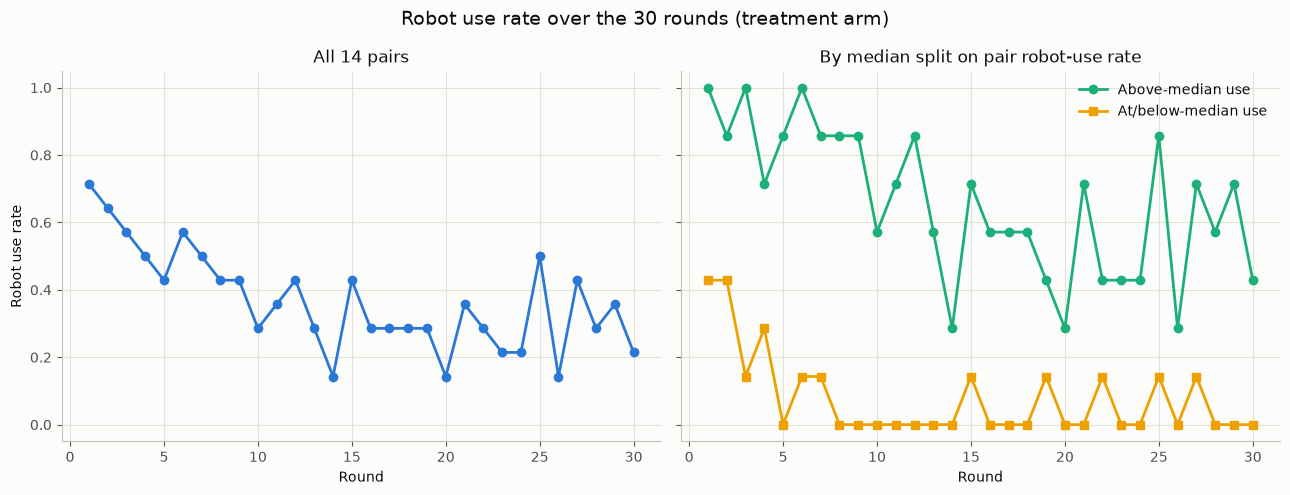

In [5]:
CHART_SURFACE = "#fcfcfb"
PRIMARY_INK = "#0b0b0b"
SECONDARY_INK = "#52514e"
GRIDLINE = "#e1e0d9"
AXIS = "#c3c2b7"
SINGLE_SERIES = "#2a78d6"
GROUP_SERIES = {"Above-median use": "#1baf7a", "At/below-median use": "#eda100"}
GROUP_MARKERS = {"Above-median use": "o", "At/below-median use": "s"}

fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor=CHART_SURFACE, sharey=True)

ax = axes[0]
ax.set_facecolor(CHART_SURFACE)
ax.plot(overall_by_round.index, overall_by_round.values, color=SINGLE_SERIES, marker="o", markersize=6, linewidth=2)
ax.set_title("All 14 pairs", color=PRIMARY_INK, fontsize=12)
ax.set_xlabel("Round", color=PRIMARY_INK)
ax.set_ylabel("Robot use rate", color=PRIMARY_INK)

ax = axes[1]
ax.set_facecolor(CHART_SURFACE)
for group in ["Above-median use", "At/below-median use"]:
    ax.plot(
        group_by_round.index, group_by_round[group],
        color=GROUP_SERIES[group], marker=GROUP_MARKERS[group], markersize=6,
        linewidth=2, label=group,
    )
ax.set_title("By median split on pair robot-use rate", color=PRIMARY_INK, fontsize=12)
ax.set_xlabel("Round", color=PRIMARY_INK)
legend = ax.legend(frameon=False, labelcolor=PRIMARY_INK)

for ax in axes:
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, color=GRIDLINE, linewidth=0.8)
    ax.set_axisbelow(True)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_color(AXIS)
    ax.tick_params(colors=SECONDARY_INK)

fig.suptitle("Robot use rate over the 30 rounds (treatment arm)", color=PRIMARY_INK, fontsize=14)
fig.tight_layout()
plt.show()

Both groups decline at a similar rate (both trends significant) -- this looks like a novelty/trust-calibration effect (heavy reliance early, tapering as players gain experience) rather than heavier users *escalating* over time. The above-median group simply starts from, and stays at, a persistently higher level throughout, never fully tapering off the way the other group does.

## Does a failed round trigger robot use in the next one?

A naive round-level test suggests yes: after a round that wasn't successful collaboration, the next round's robot-use rate nearly doubles. But that test treats 406 rounds as independent when they really come from 14 pairs -- the same non-independence problem as everywhere else in this analysis. Refitting with GEE (cluster-robust SEs) and a mixed model (random intercept per pair), alongside `round` (centered) to separate the reactive effect from the general declining-usage trend.

In [6]:
treatment_sorted = treatment.sort_values(["pair_id", "round"]).copy()
treatment_sorted["prev_outcome"] = treatment_sorted.groupby("pair_id")["outcome"].shift(1)
treatment_sorted["prev_bad"] = (treatment_sorted["prev_outcome"] != "successful collaboration").astype("Int64")
model_data = treatment_sorted.dropna(subset=["prev_outcome"]).copy()
model_data["prev_bad"] = model_data["prev_bad"].astype(int)
model_data["round_c"] = model_data["round"] - model_data["round"].mean()

print(f"n={len(model_data)} rounds (round 1 dropped, no prior round), {model_data['pair_id'].nunique()} pairs")
print()
naive_ctab = pd.crosstab(model_data["prev_bad"], model_data["either_used_robot"], normalize="index")
print("Naive (round-level, ignores clustering):")
print(naive_ctab.round(3))
chi2, p_naive, _, _ = stats.chi2_contingency(pd.crosstab(model_data["prev_bad"], model_data["either_used_robot"]))
print(f"chi2 p = {p_naive:.4f}")

n=406 rounds (round 1 dropped, no prior round), 14 pairs

Naive (round-level, ignores clustering):
either_used_robot      0      1
prev_bad                       
0                  0.699  0.301
1                  0.440  0.560
chi2 p = 0.0000


In [7]:
formula = "either_used_robot ~ round_c + prev_bad"

gee_result = smf.gee(formula, groups="pair_id", data=model_data, family=sm.families.Binomial()).fit()
print(gee_result.summary())

                               GEE Regression Results                              
Dep. Variable:           either_used_robot   No. Observations:                  406
Model:                                 GEE   No. clusters:                       14
Method:                        Generalized   Min. cluster size:                  29
                      Estimating Equations   Max. cluster size:                  29
Family:                           Binomial   Mean cluster size:                29.0
Dependence structure:         Independence   Num. iterations:                     2
Date:                     Sat, 29 Aug 2026   Scale:                           1.000
Covariance type:                    robust   Time:                         10:26:44
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.8790      0.452     -1.944      0.052      -1.765       0.007
round_c

In [8]:
mixed_result = BinomialBayesMixedGLM.from_formula(
    formula, vc_formulas={"pair": "0 + C(pair_id)"}, data=model_data,
).fit_vb()
print(mixed_result.summary())

               Binomial Mixed GLM Results
          Type Post. Mean Post. SD   SD  SD (LB) SD (UB)
--------------------------------------------------------
Intercept    M    -1.0304   0.1581                      
round_c      M    -0.1010   0.0192                      
prev_bad     M     0.5730   0.3253                      
pair         V     1.1661   0.1787 3.210   2.245   4.588
Parameter types are mean structure (M) and variance
structure (V)
Variance parameters are modeled as log standard
deviations


## Interpretation

`round_c` remains strongly significant in GEE (p = 0.002): the declining-usage trend is real and not an artifact of clustering. `prev_bad`, however, drops from a seemingly clear-cut naive result (p < 0.0001) to **not significant** once properly clustered (GEE p = 0.11) -- with only 14 independent pairs, there isn't enough power to confirm the reactive effect at conventional thresholds, even though the coefficient's direction (positive: a bad round *is* associated with more robot use next round) is consistent across both models.

Bottom line for now: the declining-usage-over-time pattern is solid; the reactive uptick in robot use immediately after a coordination failure or mutual independence round is directionally consistent but underpowered to confirm with only 14 pairs -- worth flagging as a real open question rather than a settled conclusion.

## Does robot use relate to that round's outcome?

Everything above asked what predicts robot use (time, a prior bad round). This asks the reverse question: does using the robot in a round relate to *that round's* outcome (successful collaboration, mutual independence, coordination failure)? Timing supports this direction, not the reverse -- per `public/index.js`, the design/strategy choice is blocked until `collabBelief` is submitted and the robot (if used) is consulted first, so `usedRobot` for a round is set before that round's strategy is chosen.

As with the outcome analyses elsewhere in this project, all three outcomes are compared at once with a multinomial GEE (`NominalGEE`, cluster-robust on `pair_id`, `successful_collaboration` as the reference), using `either_used_robot` (either partner consulted it that round) as the predictor.

**A caveat before looking at results**: unlike `arm`, robot use is **not randomly assigned** -- it's a choice each pair makes, and per-pair usage rates range from 0% to 100% (see above). Any association found here could reflect the robot's actual effect, or could just as easily reflect reverse causation or confounding: pairs already struggling to collaborate might lean on the tool more *because* they're struggling, without the tool being the cause of anything. This section is designed specifically to probe that distinction, not just report a raw correlation.

In [9]:
from statsmodels.genmod.generalized_estimating_equations import NominalGEE

outcome_code_map = {"mutual independence": 0, "coordination failure": 1, "successful collaboration": 2}
treatment["outcome_code"] = treatment["outcome"].map(outcome_code_map)

print(pd.crosstab(treatment["either_used_robot"], treatment["outcome"], normalize="index").round(3))

nominal_naive = NominalGEE.from_formula(
    "outcome_code ~ either_used_robot", groups="pair_id", data=treatment,
).fit()
print(nominal_naive.summary())

outcome            coordination failure  mutual independence  \
either_used_robot                                              
0                                 0.045                0.098   
1                                 0.169                0.136   

outcome            successful collaboration  
either_used_robot                            
0                                     0.857  
1                                     0.695  


                           NominalGEE Regression Results                           
Dep. Variable:                           y   No. Observations:                  840
Model:                          NominalGEE   No. clusters:                       14
Method:                        Generalized   Min. cluster size:                  60
                      Estimating Equations   Max. cluster size:                  60
Family:                       _Multinomial   Mean cluster size:                60.0
Dependence structure:  NominalIndependence   Num. iterations:                    10
Date:                     Sat, 29 Aug 2026   Scale:                           1.000
Covariance type:                    robust   Time:                         10:26:45
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept[0.0]            -2.1712      0.665     -3.267      0

This naive model says robot use is associated with a much higher rate of coordination failure specifically (`[1.0]`, coef 1.53, p = 0.015 -- rounds where the robot was used see coordination failure 16.9% of the time vs. 4.5% when it wasn't) but not with mutual independence (`[0.0]`, p = 0.447). Taken at face value this looks like "using the tool causes coordination failure," which would be a strange and unwelcome result -- exactly the kind of finding that warrants checking for confounding before it's reported as if it means that.

### Between-pair vs. within-pair robot use

Per-pair usage rates range from 0% to 100% (see above), so `either_used_robot` mixes two very different signals: (1) *which pairs* tend to rely on the robot a lot vs. not at all (a between-pair, roughly fixed trait), and (2) *within a given pair*, whether this particular round happened to be one where they used it (round-to-round variation around their own average). These are decomposed the same way a panel/clustered covariate normally would be: `robot_use_between` (that pair's own overall usage rate) and `robot_use_within` (this round's `either_used_robot` minus the pair's own rate) -- refitting `outcome_code ~ robot_use_between + robot_use_within` separates which of the two is actually doing the work in the naive result above.

In [10]:
pair_mean_use = treatment.groupby("pair_id")["either_used_robot"].transform("mean")
treatment["robot_use_between"] = pair_mean_use
treatment["robot_use_within"] = treatment["either_used_robot"] - pair_mean_use

nominal_decomposed = NominalGEE.from_formula(
    "outcome_code ~ robot_use_between + robot_use_within", groups="pair_id", data=treatment,
).fit()
print(nominal_decomposed.summary())

                           NominalGEE Regression Results                           
Dep. Variable:                           y   No. Observations:                  840
Model:                          NominalGEE   No. clusters:                       14
Method:                        Generalized   Min. cluster size:                  60
                      Estimating Equations   Max. cluster size:                  60
Family:                       _Multinomial   Mean cluster size:                60.0
Dependence structure:  NominalIndependence   Num. iterations:                    11
Date:                     Sat, 29 Aug 2026   Scale:                           1.000
Covariance type:                    robust   Time:                         10:26:45
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept[0.0]            -2.5508      0.882     -2.893      0

`robot_use_within` -- whether *this* round was a use-it round relative to that pair's own habit -- is not significant for either contrast (p = 0.20 for mutual independence, p = 0.23 for coordination failure), and the coordination-failure coefficient shrinks from 1.53 to 0.83 once the between-pair signal is separated out. Most of the naive association was a **between-pair** pattern: `robot_use_between` is a decent-sized coefficient for coordination failure (2.15) but only reaches a trend (p = 0.054) with just 14 clusters to estimate it from, and isn't significant for mutual independence (p = 0.276).

One more check: is task difficulty confounding the within-pair estimate -- do pairs reach for the robot specifically when *that round's* task is unusually hard or mismatched, which could itself explain a worse outcome regardless of the robot?

In [11]:
task_summary = pd.read_csv("task_summary.csv")
difficulty_by_index = task_summary.set_index("task_index")["task_difficulty"]
difficulty_1 = treatment["task_1"].map(difficulty_by_index).astype(int)
difficulty_2 = treatment["task_2"].map(difficulty_by_index).astype(int)
treatment["max_difficulty"] = np.maximum(difficulty_1, difficulty_2)
treatment["diff_difficulty"] = (difficulty_1 - difficulty_2).abs()

print("Robot use rate by max_difficulty:")
print(treatment.groupby("max_difficulty")["either_used_robot"].mean().round(3))
print("\nRobot use rate by diff_difficulty:")
print(treatment.groupby("diff_difficulty")["either_used_robot"].mean().round(3))

Robot use rate by max_difficulty:
max_difficulty
2    0.357
3    0.482
4    0.381
5    0.339
6    0.336
Name: either_used_robot, dtype: float64

Robot use rate by diff_difficulty:
diff_difficulty
1    0.386
2    0.339
3    0.381
4    0.339
5    0.393
Name: either_used_robot, dtype: float64


### Interpretation

Robot use rate is roughly flat across both difficulty measures (0.34-0.48 across `max_difficulty` tiers, 0.34-0.39 across `diff_difficulty`) -- no meaningful trend, so task difficulty isn't a plausible confound for the within-pair estimate above. Combined with `robot_use_within` being non-significant, there's no good evidence that a pair's own decision to consult the robot on a *particular* round is associated with that round going worse (or better) for them.

The naive-looking "robot use causes coordination failure" result is almost entirely a **between-pair** phenomenon, not a round-specific one: pairs that lean on the robot heavily overall also tend to have more coordination failure overall (a trend, p = 0.054, not confirmed with only 14 pairs). This is consistent with everything else found about robot use in this dataset -- the heaviest-use pairs (`user0041_user0042`, `user0047_user0048`) are also two of the three lowest-success pairs (see `outcome_analysis.ipynb` and `belief_manipulation_analysis.ipynb`), while one of the two pairs with *zero* robot use (`user0031_user0032`) is *also* among the lowest-success pairs. Non-use is no guarantee of success and heavy use is no guarantee of failure -- what's consistent is that **struggling pairs and heavy robot use co-occur**, which reads much more plausibly as pairs reaching for the tool *because* they're struggling (reverse causation / compensatory use) than as the tool causing the struggle. This can't be settled with observational data on which pairs weren't randomly assigned to use it -- but the round-specific, within-pair analysis here finds no evidence that the tool itself is harmful in the moment it's used.